In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_aer import Aer
from qiskit.quantum_info import partial_trace, purity, DensityMatrix
from scipy.optimize import minimize
from scipy.linalg import logm

# Use the styling from your paper's visualizations [cite: 215, 231, 282]
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 2,
})

In [5]:
# -------------------------------------------------
# Core Utilities
# -------------------------------------------------
def generate_random_antisymmetric_matrix(n, rng):
    """Generates the matrix A satisfying A^T = -A [cite: 302, 303]"""
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            A[i, j] = rng.uniform(-1, 1)
            A[j, i] = -A[i, j]
    return A

def single_qubit_purity_corrected(state, n_qubits):
    """
    Correctly calculates average single-qubit purity[cite: 323, 329].
    Min value = 0.5 (Maximally Entangled), Max value = 1.0 (Separable).
    """
    dm = DensityMatrix(state)
    purities = []
    for q in range(n_qubits):
        # To find purity of qubit q, trace out all OTHER qubits
        q_to_trace = [i for i in range(n_qubits) if i != q]
        rho_q = partial_trace(dm, q_to_trace)
        purities.append(purity(rho_q).real)
    return np.mean(purities)

# -------------------------------------------------
# Parameterized P-layer Variants [cite: 206, 321]
# -------------------------------------------------
def create_parameterized_P_variant(n_qubits, variant='cnot'):
    qc = QuantumCircuit(n_qubits)
    params = ParameterVector(f"θ_{variant}", 2 * n_qubits)
    p_idx = 0

    # Initial rotation layer
    for q in range(n_qubits):
        qc.ry(params[p_idx], q)
        p_idx += 1

    # Entanglement mechanism based on paper variants [cite: 198, 341]
    if variant == 'cnot':
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
    elif variant == 'cz':
        for i in range(n_qubits - 1):
            qc.cz(i, i + 1)
    elif variant == 'toffoli' and n_qubits >= 3:
        # Toffoli creates multipartite correlations [cite: 268, 345]
        for i in range(n_qubits - 2):
            qc.ccx(i, i + 1, i + 2)

    # Final rotation layer
    for q in range(n_qubits):
        qc.ry(params[p_idx], q)
        p_idx += 1

    return qc, params

# -------------------------------------------------
# Full Circuit Construction [cite: 206]
# -------------------------------------------------
def create_full_bench_circuit(n_qubits, variant):
    qcP, paramsP = create_parameterized_P_variant(n_qubits, variant)

    # Diagonal layer [cite: 321]
    qcD = QuantumCircuit(n_qubits)
    pD = ParameterVector(f"θ_D_{variant}", n_qubits)
    for q in range(n_qubits):
        qcD.rz(pD[q], q)

    # Fourier layer [cite: 247]
    qcF = QuantumCircuit(n_qubits)
    pF = ParameterVector(f"θ_F_{variant}", n_qubits * (n_qubits - 1) // 2)
    idx = 0
    for i in range(n_qubits):
        qcF.h(i)
        for j in range(i + 1, n_qubits):
            qcF.cp(pF[idx], j, i)
            idx += 1

    # Lambda layer
    qcL = QuantumCircuit(n_qubits)
    pL = ParameterVector(f"α_Λ_{variant}", n_qubits)
    for q in range(n_qubits):
        qcL.rz(pL[q], q)

    # Construct U(θ) = P D F Λ F† D† P†
    qc = (
        qcP.compose(qcD)
           .compose(qcF)
           .compose(qcL)
           .compose(qcF.inverse())
           .compose(qcD.inverse())
           .compose(qcP.inverse())
    )

    return qc, list(qc.parameters), qcP

Starting optimization benchmark...
 Trial 1/5
 Trial 2/5
 Trial 3/5
 Trial 4/5
 Trial 5/5


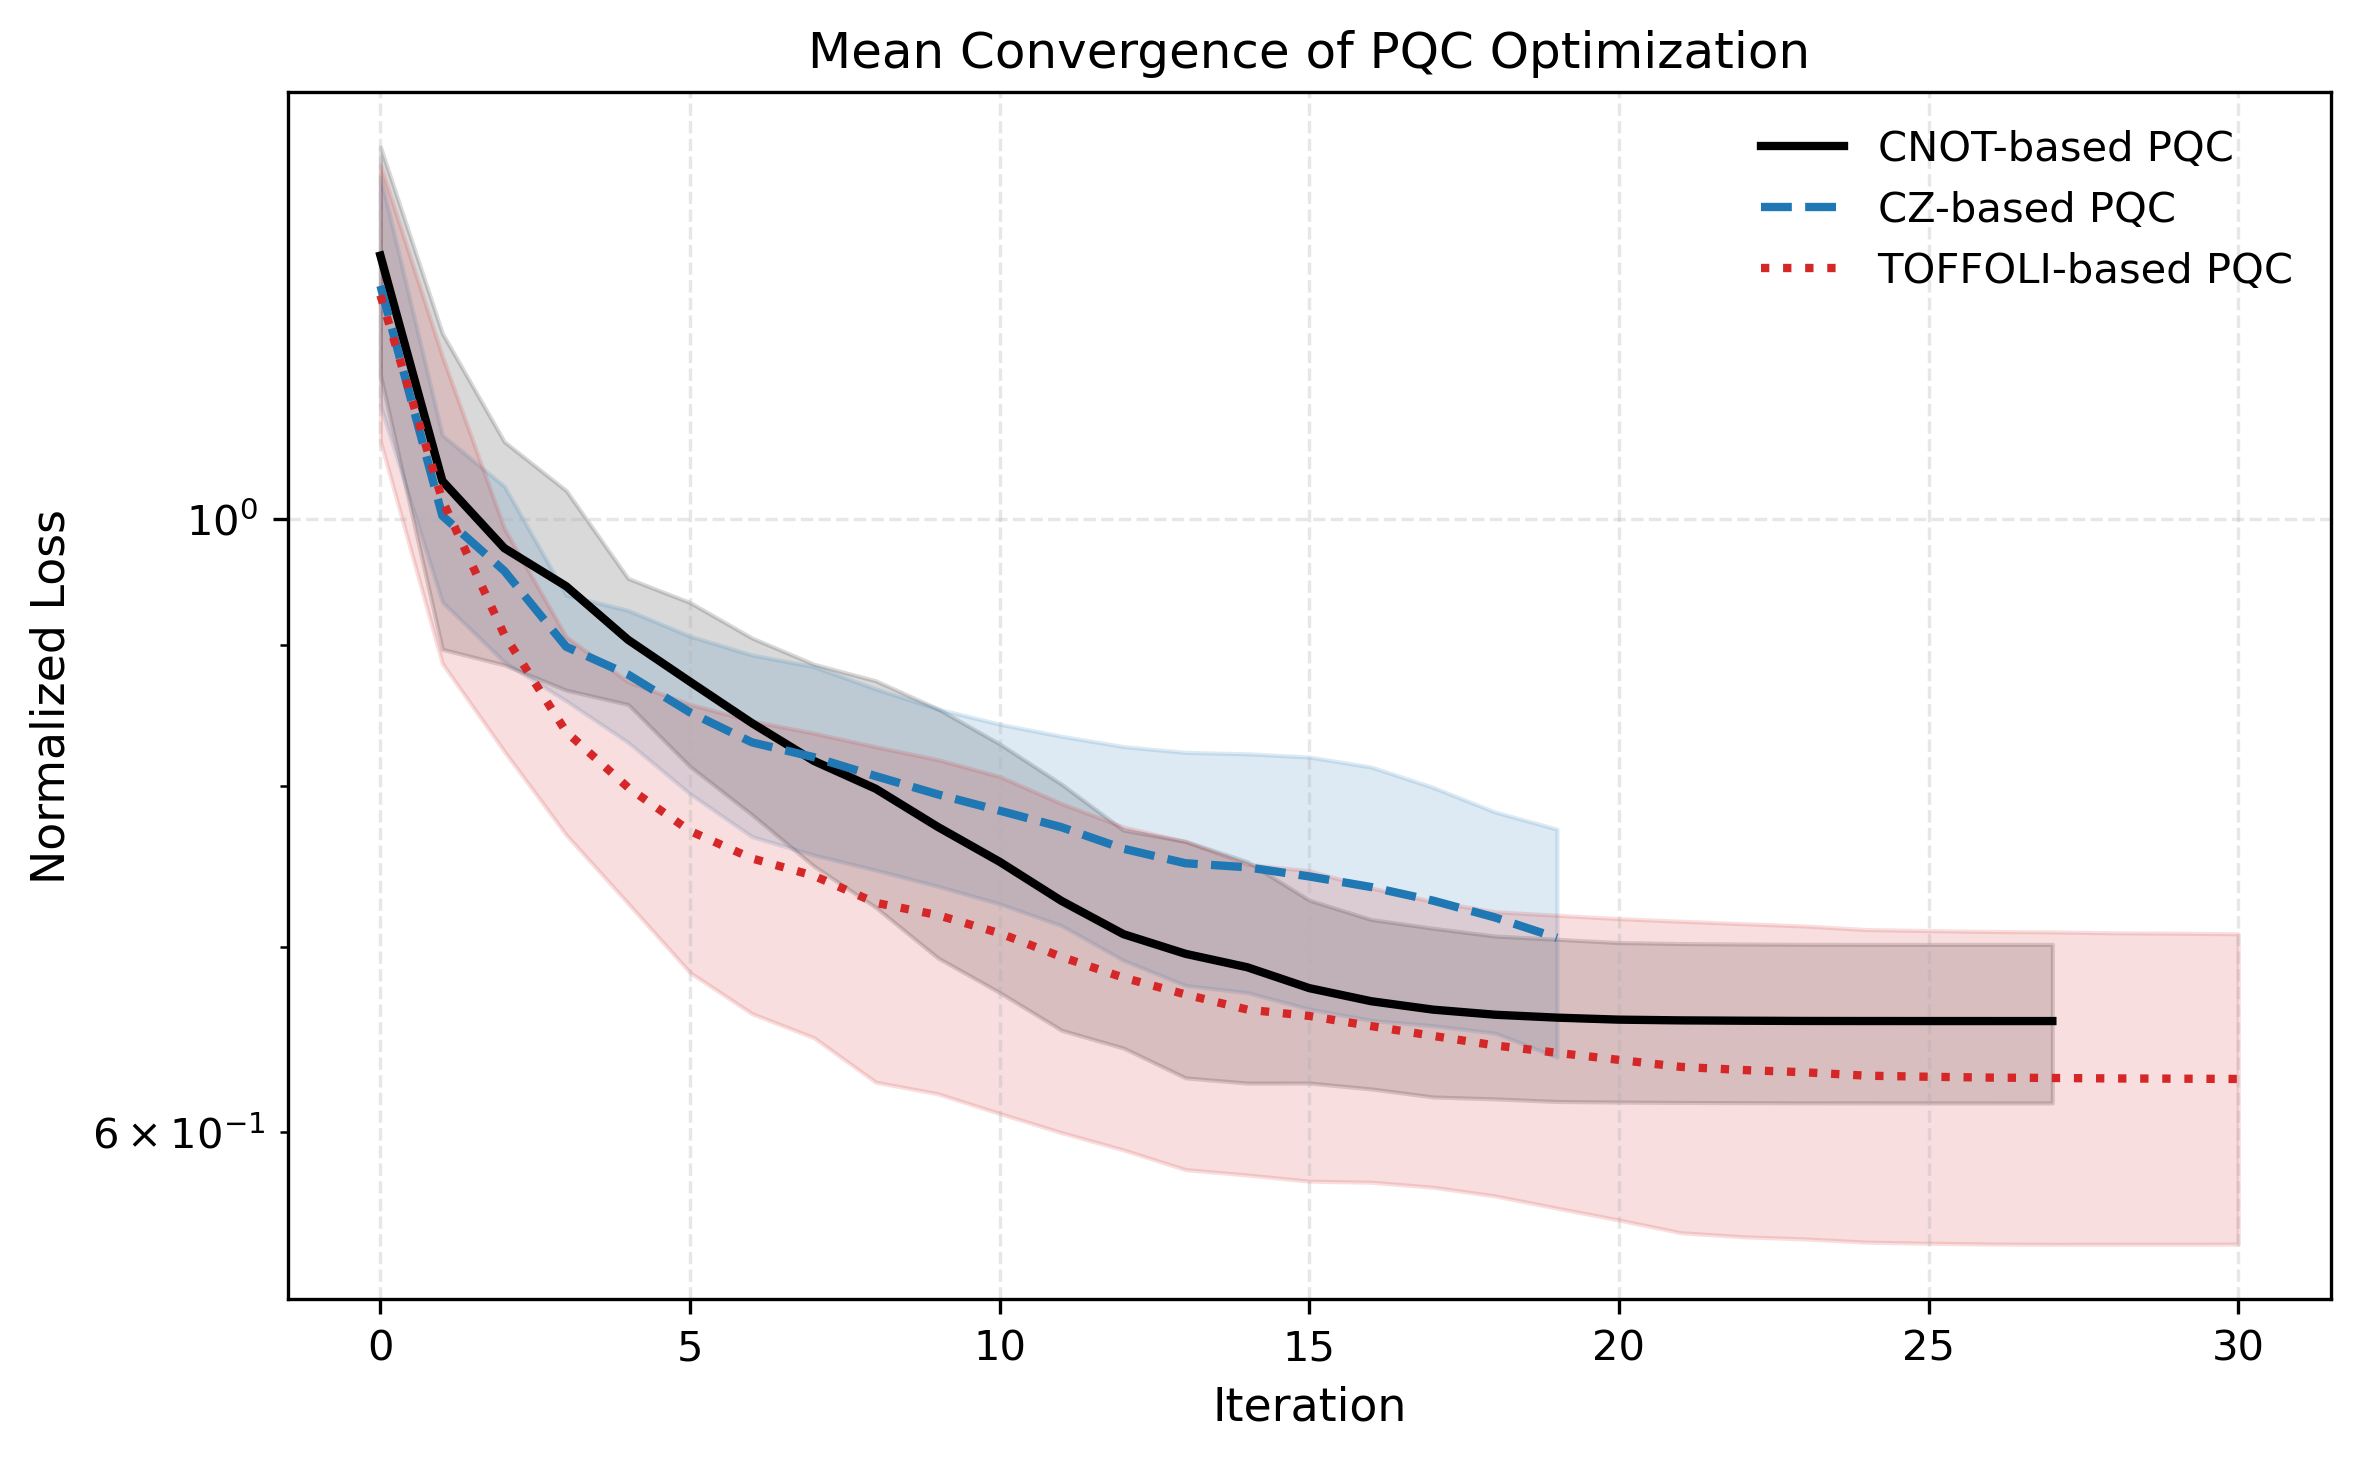

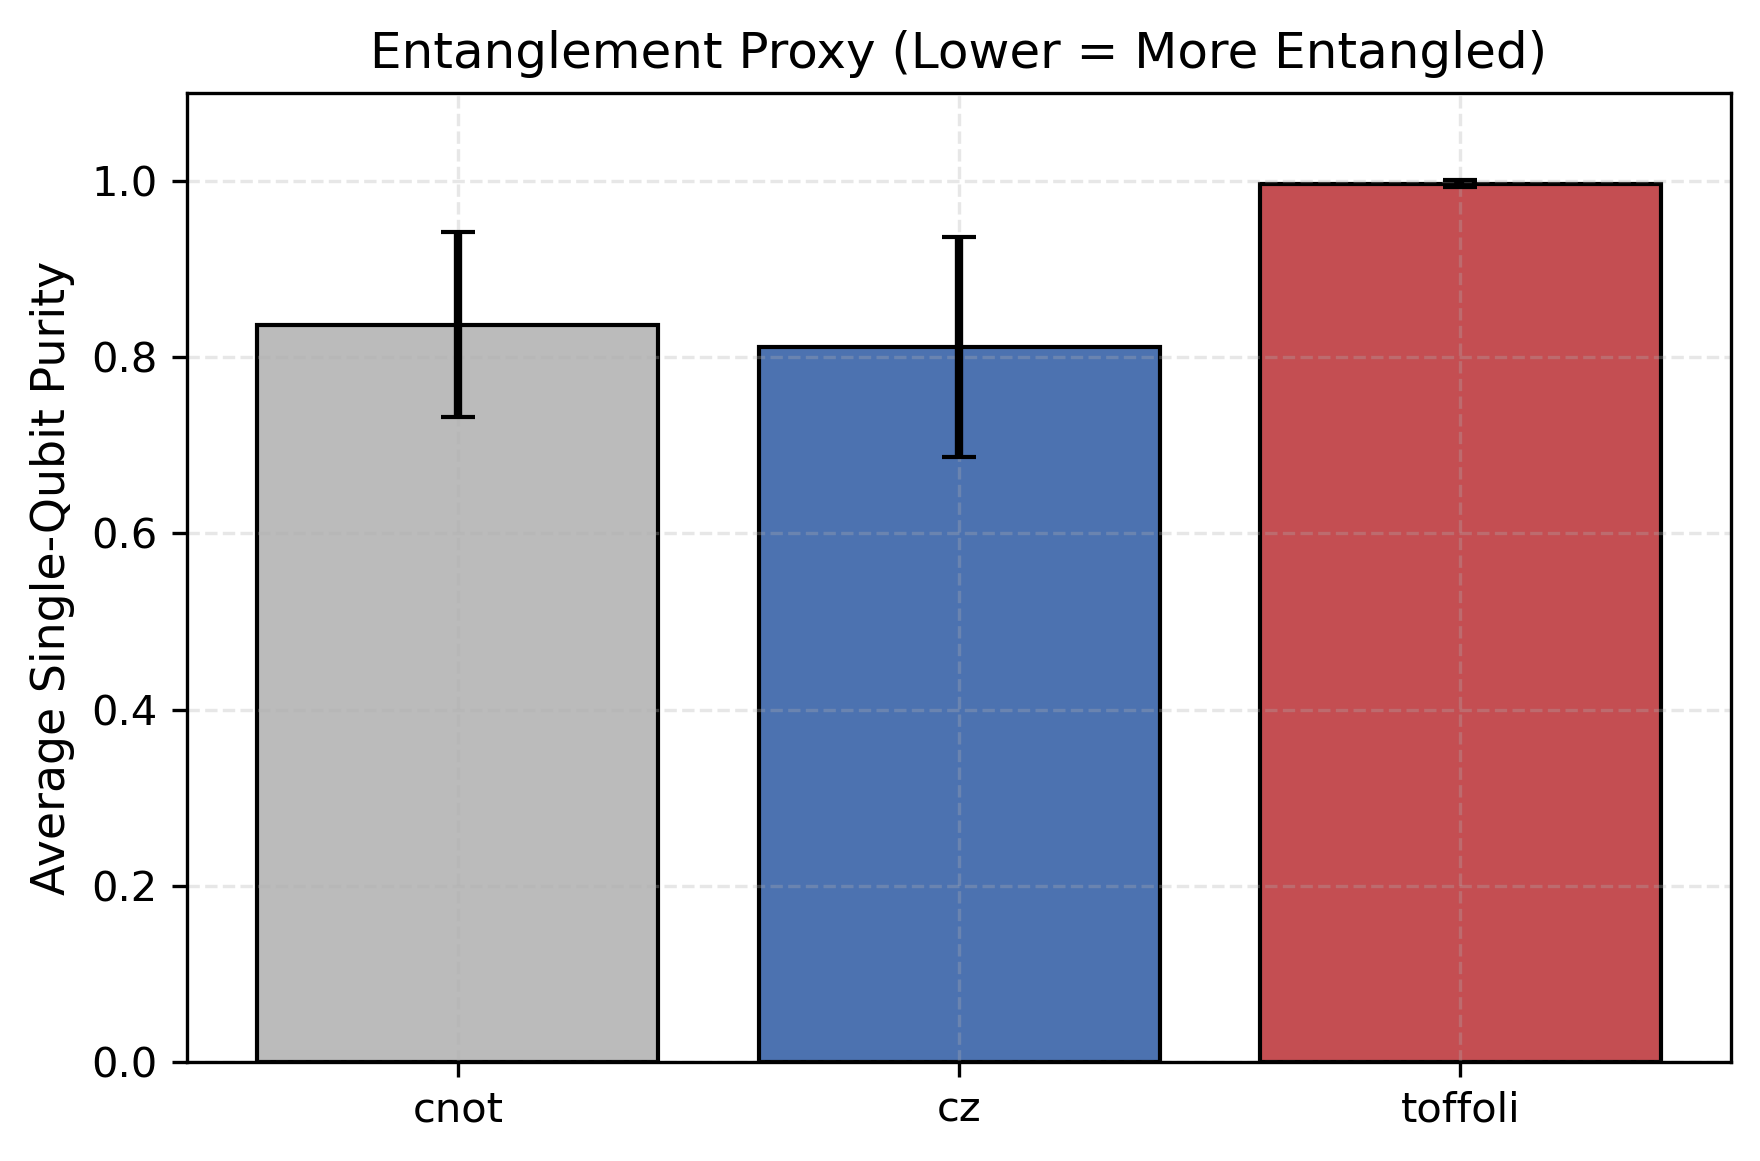

In [6]:
# -------------------------------------------------
# Benchmark Runner
# -------------------------------------------------
from qiskit.quantum_info import Statevector
def run_benchmark():
    n_qubits = 3
    n_trials = 5  # Reduced for speed; increase for final results
    max_iter = 50
    threshold = 1e-2

    rng = np.random.default_rng(42)
    variants = ["cnot", "cz", "toffoli"]
    simulator = Aer.get_backend("unitary_simulator")

    final_losses = {v: [] for v in variants}
    loss_histories = {v: [] for v in variants}
    purities = {v: [] for v in variants}

    print("Starting optimization benchmark...")

    for trial in range(n_trials):
        print(f" Trial {trial + 1}/{n_trials}")
        # Target unitary U = exp(A) [cite: 327, 330]
        Atarget = generate_random_antisymmetric_matrix(2**n_qubits, rng)
        normA = np.linalg.norm(Atarget, 'fro')

        for v in variants:
            qc, params, qcP = create_full_bench_circuit(n_qubits, v)
            compiled = transpile(qc, simulator)
            loss_track = []

            def objective(x):
                bound = compiled.assign_parameters(dict(zip(params, x)))
                Uest = simulator.run(bound).result().get_unitary().data
                # Normalized loss metric 
                return np.linalg.norm(logm(Uest) - Atarget, 'fro') / normA

            def callback(xk):
                loss_track.append(objective(xk))

            x0 = rng.uniform(0, 2*np.pi, len(params))
            res = minimize(objective, x0, method='L-BFGS-B', 
                           callback=callback, 
                           options={'maxiter': max_iter})

            final_losses[v].append(res.fun)
            loss_histories[v].append(loss_track)

            # Measure entanglement proxy at optimized parameters [cite: 323]
            p_bound = qcP.assign_parameters(
                dict(zip(qcP.parameters, res.x[:len(qcP.parameters)]))
            )
            state =Statevector.from_instruction(p_bound)
            purities[v].append(single_qubit_purity_corrected(state, n_qubits))

    # -------------------------------------------------
    # Visualization [Matches Fig 4, 5, 6 in Paper]
    # -------------------------------------------------
    styles = {
        "cnot": {"ls": "-", "color": "black"},
        "cz": {"ls": "--", "color": "tab:blue"},
        "toffoli": {"ls": ":", "color": "tab:red"},
    }

    # Plot 1: Mean Convergence [cite: 284, 304]
    plt.figure(figsize=(8, 5))
    for v in variants:
        min_len = min(len(h) for h in loss_histories[v])
        data = np.array([h[:min_len] for h in loss_histories[v]])
        mean, std = np.mean(data, axis=0), np.std(data, axis=0)
        plt.plot(mean, linestyle=styles[v]["ls"], color=styles[v]["color"], label=f"{v.upper()}-based PQC")
        plt.fill_between(range(min_len), mean - std, mean + std, color=styles[v]["color"], alpha=0.15)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Normalized Loss")
    plt.title("Mean Convergence of PQC Optimization")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Plot 2: Entanglement Proxy [cite: 316, 317]
    plt.figure(figsize=(6, 4))
    p_means = [np.mean(purities[v]) for v in variants]
    p_stds = [np.std(purities[v]) for v in variants]
    plt.bar(variants, p_means, yerr=p_stds, capsize=4, color=["#BBBBBB", "#4C72B0", "#C44E52"], edgecolor="black")
    plt.ylabel("Average Single-Qubit Purity")
    plt.ylim(0, 1.1)
    plt.title("Entanglement Proxy (Lower = More Entangled)")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_benchmark()